# Chapter 7: STL + XGBoost for Time Series Forecasting

## Learning Objectives

In this chapter, we build an advanced machine learning forecasting pipeline for household energy consumption data.

You will learn how to:

- Prepare and preprocess real-world time series data
- Perform STL decomposition to extract trend and seasonality
- Engineer lag and rolling statistical features
- Encode cyclical time patterns using sine and cosine transformations
- Train an XGBoost model for forecasting
- Evaluate forecasting performance using RMSE and MAE
- Visualize actual vs predicted energy consumption

This notebook demonstrates a practical forecasting workflow commonly used in modern time series machine learning systems.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

## 1. Load Data

In [12]:
file_path = "household_power_consumption.txt"

print("Reading dataset...")

df = pd.read_csv(
    file_path,
    sep=';',
    na_values=['?'],
    low_memory=False
)

# Clean columns
df.columns = df.columns.str.strip()
print(df.columns)
print(df.shape)

Reading dataset...
Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')
(5000, 9)


In [13]:
# Build datetime
df['Date'] = df['Date'].astype(str).str.strip()
df['Time'] = df['Time'].astype(str).str.strip()

df['Date_Time_Str'] = df['Date'] + ' ' + df['Time']

df['Date_Time'] = pd.to_datetime(
    df['Date_Time_Str'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Remove invalid rows
df.dropna(subset=['Date_Time'], inplace=True)

# Set datetime index
df.set_index('Date_Time', inplace=True)
df.sort_index(inplace=True)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Date_Time_Str
Date_Time,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,16/12/2006 17:24:00
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,16/12/2006 17:25:00
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,16/12/2006 17:26:00
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,16/12/2006 17:27:00
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,16/12/2006 17:28:00


## 2. Target Variable

In [14]:
# Rename target variable
df_target = df[['Global_active_power']].rename(
    columns={'Global_active_power': 'Energy_Consumption'}
)

# Covert target variable to numeric
df_target['Energy_Consumption'] = pd.to_numeric(
    df_target['Energy_Consumption'],
    errors='coerce'
)

# Fill missing values
df_target['Energy_Consumption'] = (
    df_target['Energy_Consumption']
    .ffill(limit=1440)
)

df_target.dropna(inplace=True)
df_target.head()

,Energy_Consumption
Date_Time,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


## 3. Resample to hourly

In [15]:
print("Resampling to hourly data...")

df_hourly = (
    df_target
    .resample('h')
    .mean()
    .ffill()
)

print(f"Total hourly rows: {len(df_hourly)}")

Resampling to hourly data...
Total hourly rows: 84


Plotting raw energy consumption...


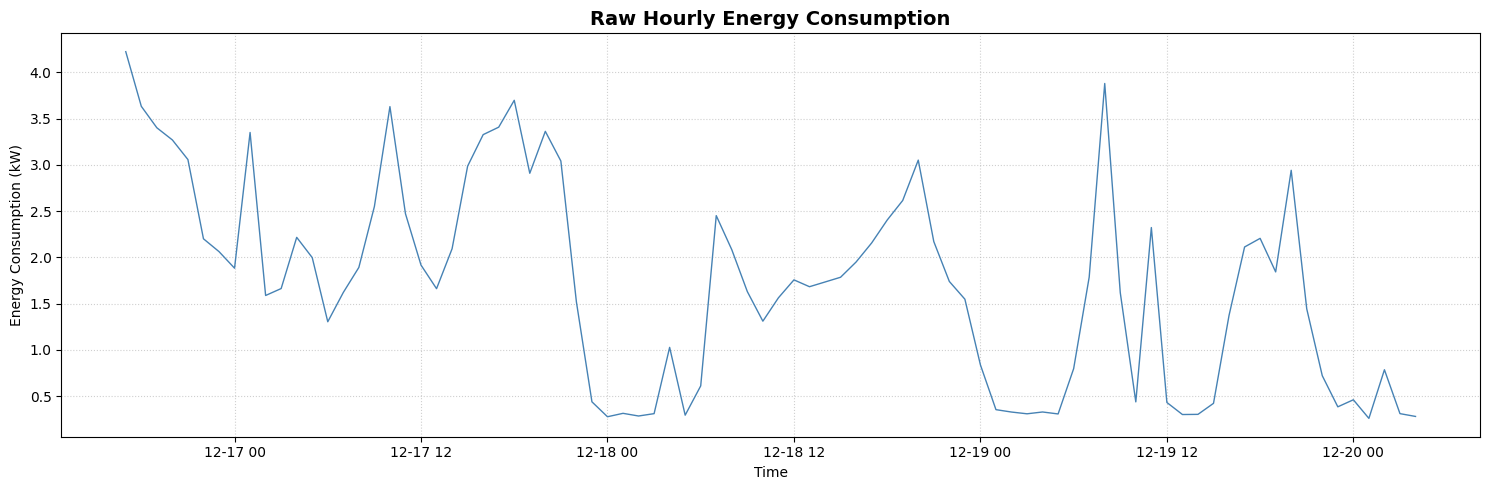

In [ ]:
# 2.1 RAW DATA PLOT (HOURLY ENERGY CONSUMPTION)
print("Plotting raw energy consumption...")

plt.figure(figsize=(15, 5), dpi=100)

plt.plot(
    df_hourly.index,
    df_hourly["Energy_Consumption"],
    color="steelblue",
    linewidth=1
)

plt.title(
    "Raw Hourly Energy Consumption",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Time")
plt.ylabel("Energy Consumption (kW)")
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 4. STL Decomposition

Performing STL decomposition (EDA only)...


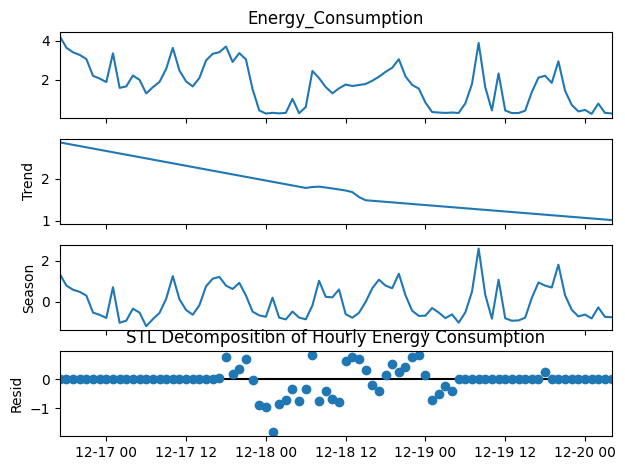

In [17]:
print("Performing STL decomposition (EDA only)...")

stl = STL(
    df_hourly['Energy_Consumption'],
    period=24,
    robust=True
)

stl_result = stl.fit()

stl_result.plot()
plt.title("STL Decomposition of Hourly Energy Consumption")
plt.show()

## 5. Feature Engineering

In [ ]:

def build_feature_space(df_in):

    df_out = df_in.copy()

    
    # Cyclical Time Features
    df_out["hour_sin"] = np.sin(
        2 * np.pi * df_out.index.hour / 24
    )

    df_out["hour_cos"] = np.cos(
        2 * np.pi * df_out.index.hour / 24
    )

    df_out["dow_sin"] = np.sin(
        2 * np.pi * df_out.index.dayofweek / 7
    )

    df_out["dow_cos"] = np.cos(
        2 * np.pi * df_out.index.dayofweek / 7
    )

     
    # Dynamic Lag Selection
    data_size = len(df_out)

    if data_size < 500:
        lags = [1, 2, 3, 24]
    else:
        lags = [1, 2, 3, 24, 48, 168]

    
    # Lag Features
    for lag in lags:

        df_out[f"lag_{lag}"] = (
            df_out["Energy_Consumption"]
            .shift(lag)
        )


    # Rolling Features

    rolling_window = 24 if data_size >= 500 else 6

    df_out["rolling_mean"] = (
        df_out["Energy_Consumption"]
        .shift(1)
        .rolling(rolling_window)
        .mean()
    )

    df_out["rolling_std"] = (
        df_out["Energy_Consumption"]
        .shift(1)
        .rolling(rolling_window)
        .std()
    )

    df_out["rolling_max"] = (
        df_out["Energy_Consumption"]
        .shift(1)
        .rolling(rolling_window)
        .max()
    )

    df_out["rolling_min"] = (
        df_out["Energy_Consumption"]
        .shift(1)
        .rolling(rolling_window)
        .min()
    )

    return df_out

print("Building features...")

df_features = build_feature_space(df_hourly)

# Remove missing rows
df_features.dropna(inplace=True)

print("Total rows after feature engineering:", len(df_features))


Building features...
Total rows after feature engineering: 60


## 6. Train / Test Split

In [21]:

if len(df_features) < 500:
    test_horizon = 24
else:
    test_horizon = 168

# Safety check
if len(df_features) <= test_horizon:
    raise ValueError(
        "Not enough rows after feature engineering."
    )

train = df_features.iloc[:-test_horizon]
test = df_features.iloc[-test_horizon:]

X_train = train.drop(columns=["Energy_Consumption"])
y_train = train["Energy_Consumption"]

X_test = test.drop(columns=["Energy_Consumption"])
y_test = test["Energy_Consumption"]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows : {len(X_test)}")

Training rows: 36
Testing rows : 24


## 7. XGBOOST Model

In [22]:

print("Training XGBoost model...")

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=2.0,
    gamma=0.1,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

Training XGBoost model...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

## 8. Predictions

In [23]:
print("Generating predictions...")

pred = model.predict(X_test)

pred_series = pd.Series(
    pred,
    index=y_test.index
)

# Prevent negative values
pred_series = pred_series.clip(lower=0)

Generating predictions...


## 9. Evaluation

In [24]:

rmse = np.sqrt(
    mean_squared_error(y_test, pred_series)
)

mae = mean_absolute_error(
    y_test,
    pred_series
)

print("\\n==============================")
print("Forecast Performance")
print("==============================")

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")


\n==============================
Forecast Performance
RMSE: 0.7688
MAE : 0.5784


## 10. Actual VS predicted table

In [25]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred_series.values
}, index=y_test.index)

print("\\nActual vs Predicted:")
print(comparison_df.head(20))

\nActual vs Predicted:
                       Actual  Predicted
Date_Time                               
2006-12-19 05:00:00  0.306667   0.671521
2006-12-19 06:00:00  0.796333   0.635097
2006-12-19 07:00:00  1.785633   1.483255
2006-12-19 08:00:00  3.879033   1.815763
2006-12-19 09:00:00  1.617767   1.990054
2006-12-19 10:00:00  0.437133   1.511822
2006-12-19 11:00:00  2.321633   1.255784
2006-12-19 12:00:00  0.430667   1.823533
2006-12-19 13:00:00  0.300467   1.215459
2006-12-19 14:00:00  0.302133   1.245268
2006-12-19 15:00:00  0.421367   1.487837
2006-12-19 16:00:00  1.372133   1.657566
2006-12-19 17:00:00  2.111500   1.778209
2006-12-19 18:00:00  2.204700   1.987413
2006-12-19 19:00:00  1.842100   1.973756
2006-12-19 20:00:00  2.940533   1.738133
2006-12-19 21:00:00  1.442867   1.941748
2006-12-19 22:00:00  0.720000   0.753590
2006-12-19 23:00:00  0.383700   0.587672
2006-12-20 00:00:00  0.459833   0.359940


## 11. Visualization

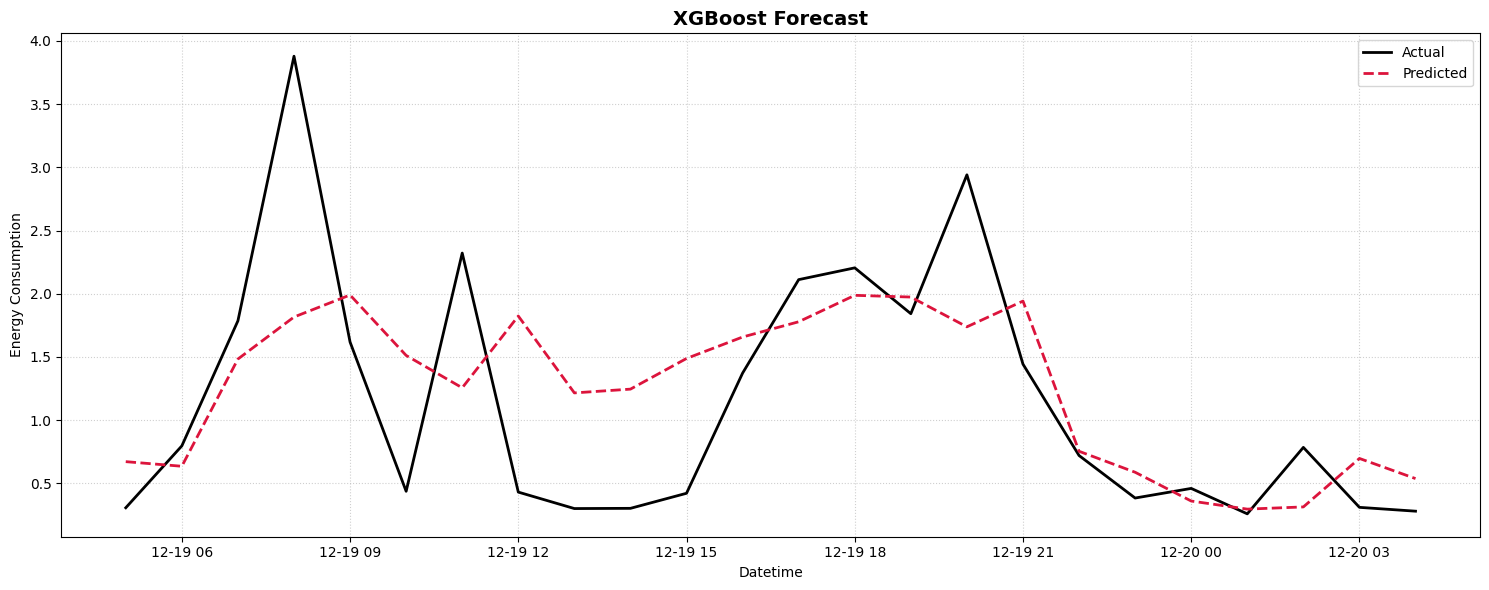

In [26]:
plt.figure(figsize=(15, 6), dpi=100)

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual",
    color="black",
    linewidth=2
)

plt.plot(
    pred_series.index,
    pred_series.values,
    label="Predicted",
    color="crimson",
    linestyle="--",
    linewidth=2
)

plt.title(
    "XGBoost Forecast",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Datetime")
plt.ylabel("Energy Consumption")

plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


## Chapter Summary

In this chapter, we combined classical time series decomposition with modern machine learning.

### Key Concepts Covered

- STL decomposition separates a series into:
  - Trend
  - Seasonal
  - Residual components

- Lag features help the model learn temporal dependence.

- Rolling statistics help capture local volatility and recent behavior.

- Cyclical encoding allows machine learning models to understand repeating calendar patterns.

- XGBoost is powerful for nonlinear forecasting problems because it can model complex interactions between features.

### Important Observation

Traditional recursive forecasting can accumulate errors over time.  
This notebook instead uses direct forecasting on engineered features, producing more stable predictions.

### Next Step

The next chapter can extend this system toward:

- Multi-step forecasting
- Probabilistic forecasting
- Hyperparameter tuning
- Feature importance analysis
- Deep learning approaches such as LSTM and Transformers
